## Bank loan Analysis Report

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.express as px

In [4]:
df = pd.read_excel(r"E:\Projects\Finance Domain-Bank Loans Analysis Using Python\financial_loan.xlsx")

In [5]:
df.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


In [6]:
print("no of rows:",df.shape[0])

no of rows: 38576


In [7]:
print("no of columns:",df.shape[1])

no of columns: 24


### Data Types

In [8]:
df.dtypes

id                                int64
address_state                       str
application_type                    str
emp_length                          str
emp_title                        object
grade                               str
home_ownership                      str
issue_date               datetime64[us]
last_credit_pull_date    datetime64[us]
last_payment_date        datetime64[us]
loan_status                         str
next_payment_date        datetime64[us]
member_id                         int64
purpose                             str
sub_grade                           str
term                                str
verification_status                 str
annual_income                   float64
dti                             float64
installment                     float64
int_rate                        float64
loan_amount                       int64
total_acc                         int64
total_payment                     int64
dtype: object

In [9]:
df.describe()

,id,issue_date,last_credit_pull_date,last_payment_date,next_payment_date,member_id,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
count,3.857600e+04,38576,38576,38576,38576,3.857600e+04,3.857600e+04,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000
mean,6.810371e+05,2021-07-16 02:31:35.562007,2021-06-08 13:36:34.193280,2021-06-26 09:52:08.909166,2021-07-26 20:42:20.605557,8.476515e+05,6.964454e+04,0.133274,326.862965,0.120488,11296.066855,22.132544,12263.348533
min,5.473400e+04,2021-01-01 00:00:00,2021-01-08 00:00:00,2021-01-08 00:00:00,2021-02-08 00:00:00,7.069900e+04,4.000000e+03,0.000000,15.690000,0.054200,500.000000,2.000000,34.000000
25%,5.135170e+05,2021-04-11 00:00:00,2021-04-15 00:00:00,2021-03-16 00:00:00,2021-04-16 00:00:00,6.629788e+05,4.150000e+04,0.082100,168.450000,0.093200,5500.000000,14.000000,5633.000000
50%,6.627280e+05,2021-07-11 00:00:00,2021-05-16 00:00:00,2021-06-14 00:00:00,2021-07-14 00:00:00,8.473565e+05,6.000000e+04,0.134200,283.045000,0.118600,10000.000000,20.000000,10042.000000
75%,8.365060e+05,2021-10-11 00:00:00,2021-08-13 00:00:00,2021-09-15 00:00:00,2021-10-15 00:00:00,1.045652e+06,8.320050e+04,0.185900,434.442500,0.145900,15000.000000,29.000000,16658.000000
max,1.077501e+06,2021-12-12 00:00:00,2022-01-20 00:00:00,2021-12-15 00:00:00,2022-01-15 00:00:00,1.314167e+06,6.000000e+06,0.299900,1305.190000,0.245900,35000.000000,90.000000,58564.000000
std,2.113246e+05,NaN,NaN,NaN,NaN,2.668105e+05,6.429368e+04,0.066662,209.092000,0.037164,7460.746022,11.392282,9051.104777


### Total Loan Applications

In [10]:
total_loan_applications = df['id'].count()
print("Total Loan Applications:",total_loan_applications)

Total Loan Applications: 38576


### Month to Date Total Loan Applications

In [11]:
latest_issue_date = df["issue_date"].max()
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month

mtd_data = df[(df["issue_date"].dt.year == latest_year) & (df["issue_date"].dt.month == latest_month)]
mtd_total_applications = mtd_data["id"].count()
print("MTD Loan Applications for December 2021:",mtd_total_applications)

MTD Loan Applications for December 2021: 4314


### Total Funded Amount

In [12]:
total_funded_amount = df["loan_amount"].sum()
total_funded_amount_millions = total_funded_amount/1000000
print("Total Funded Amount: ${:.2f}M".format(total_funded_amount_millions))

Total Funded Amount: $435.76M


### MTD - Total Funded Amount

In [13]:
latest_issue_date = df["issue_date"].max()
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month

mtd_data = df[(df["issue_date"].dt.year == latest_year) & (df["issue_date"].dt.month == latest_month)]
mtd_total_funded_amount = mtd_data["loan_amount"].sum()
mtd_total_funded_amount_million = mtd_total_funded_amount/1000000
print("MTD Total Funded Amount for December 2021: ${:.2f}M".format(mtd_total_funded_amount_million))

MTD Total Funded Amount for December 2021: $53.98M


### Total Amount Recieved

In [14]:
total_amount_recieved = df["total_payment"].sum()
total_amount_received_millions = total_amount_recieved /1000000
print("Total Amount Recieved: ${:.2f}M".format(total_amount_received_millions))

Total Amount Recieved: $473.07M


### MTD - Total Amount Received

In [15]:
latest_issue_date = df["issue_date"].max()
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month

mtd_data = df[(df["issue_date"].dt.year == latest_year) & (df["issue_date"].dt.month == latest_month)]
mtd_total_amount_recieved = mtd_data["total_payment"].sum()
mtd_total_amount_recieved_millions = mtd_total_amount_recieved/1000000
print("MTD Total Amount Received for December 2021: ${:.2f}M".format(mtd_total_amount_recieved_millions))

MTD Total Amount Received for December 2021: $58.07M


### Average Interest Rate

In [16]:
avg_int_rate = df["int_rate"].mean()*100
print("Average Int rate: {:.2f}%".format(avg_int_rate))

Average Int rate: 12.05%


### Average Debt To Income Ratio(DTI)

In [17]:
avg_dti = df["dti"].mean()*100
print("Average DTI: {:.2f}%".format(avg_dti))

Average DTI: 13.33%


### Good Loan Metrics

In [18]:
total_loan_applications = df["id"].count()

good_loan = df[df["loan_status"].isin(["Current","Fully Paid"])]
good_loan_applications = good_loan["id"].count()
good_loan_funded_amount = good_loan["loan_amount"].sum()
good_loan_received_amount = good_loan["total_payment"].sum()
good_loan_percentage = good_loan_applications/total_loan_applications *100

good_loan_funded_amount_millions = good_loan_funded_amount/1000000
good_loan_received_amount_millions =good_loan_received_amount/1000000

print("Good Loan Applications:",good_loan_applications)
print("Good Loan Funded Amount: ${:.2f}M".format(good_loan_funded_amount_millions))
print("Good Loan Received Amount: ${:.2f}M".format(good_loan_received_amount_millions))
print("Good Loan Percentage: {:.2f}%".format(good_loan_percentage))

Good Loan Applications: 33243
Good Loan Funded Amount: $370.22M
Good Loan Received Amount: $435.79M
Good Loan Percentage: 86.18%


### Bad Loan Metrics

In [19]:
total_loan_applications = df["id"].count()

bad_loan = df[df["loan_status"].isin(["Charged Off"])]
bad_loan_applications = bad_loan["id"].count()
bad_loan_funded_amount = bad_loan["loan_amount"].sum()
bad_loan_received_amount = bad_loan["total_payment"].sum()
bad_loan_percentage = bad_loan_applications/total_loan_applications *100

bad_loan_funded_amount_millions = bad_loan_funded_amount/1000000
bad_loan_received_amount_millions =bad_loan_received_amount/1000000

print("Bad Loan Applications:",bad_loan_applications)
print("Bad Loan Funded Amount: ${:.2f}M".format(bad_loan_funded_amount_millions))
print("Bad Loan Received Amount: ${:.2f}M".format(bad_loan_received_amount_millions))
print("Bad Loan Percentage: {:.2f}%".format(bad_loan_percentage))

Bad Loan Applications: 5333
Bad Loan Funded Amount: $65.53M
Bad Loan Received Amount: $37.28M
Bad Loan Percentage: 13.82%


### Monthly Trends by Issue Date for Total Funded Amount

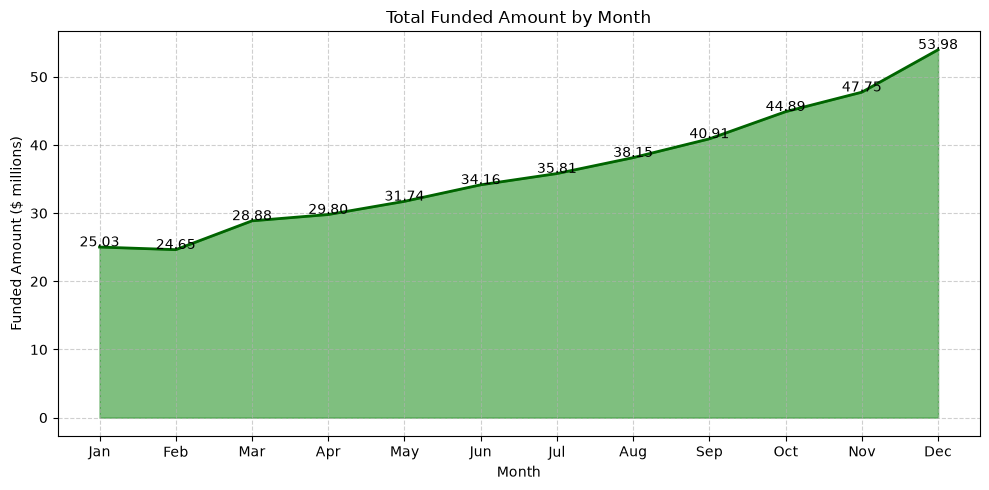

In [28]:
# Sort by date
df = df.sort_values("issue_date")

# Create month name
df["month"] = df["issue_date"].dt.strftime("%b")

# Calculate total funded amount for each month
monthly_funded = df.groupby("month")["loan_amount"].sum()

# Arrange months from January to December
month_order = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

monthly_funded = monthly_funded.reindex(month_order)

# Convert to millions
monthly_funded = monthly_funded / 1000000

# Create chart
plt.figure(figsize=(10, 5))

plt.fill_between(
    monthly_funded.index,
    monthly_funded.values,
    alpha=0.5,
    color = 'green'
)

plt.plot(
    monthly_funded.index,
    monthly_funded.values,
    linewidth=2,
    color='darkgreen'
)

# Add values
for i, value in enumerate(monthly_funded.values):
    plt.text(
        i,
        value + 0.1,
        f"{value:.2f}",
        ha="center"
    )

plt.title("Total Funded Amount by Month")
plt.xlabel("Month")
plt.ylabel("Funded Amount ($ millions)")

plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

### Monthly Trends by issue date for Total Amount Received

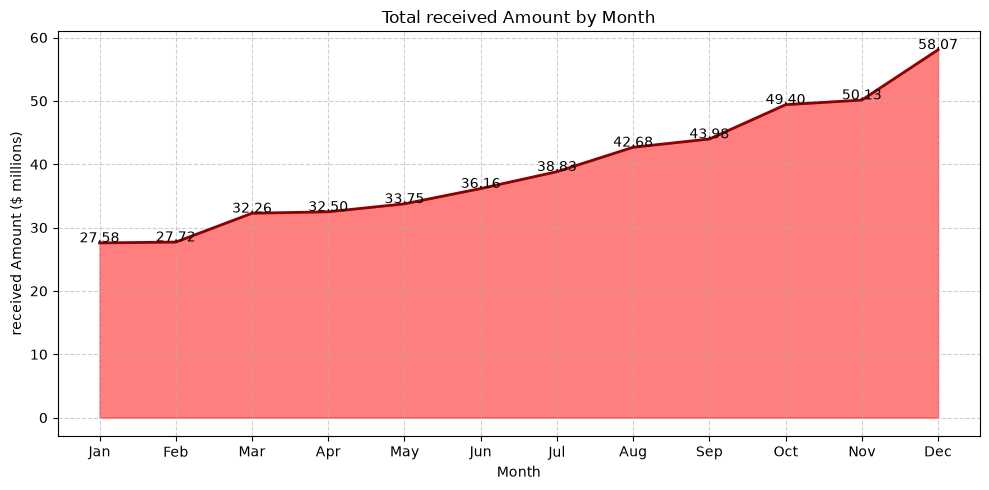

In [29]:
# Sort by date
df = df.sort_values("issue_date")

# Create month name
df["month"] = df["issue_date"].dt.strftime("%b")

# Calculate total received amount for each month
monthly_received = df.groupby("month")["total_payment"].sum()

# Arrange months from January to December
month_order = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

monthly_received = monthly_received.reindex(month_order)

# Convert to millions
monthly_received = monthly_received / 1000000

# Create chart
plt.figure(figsize=(10, 5))

plt.fill_between(
    monthly_received.index,
    monthly_received.values,
    alpha=0.5,
    color = 'red'
)

plt.plot(
    monthly_received.index,
    monthly_received.values,
    linewidth=2,
    color = 'darkred'
)

# Add values
for i, value in enumerate(monthly_received.values):
    plt.text(
        i,
        value + 0.1,
        f"{value:.2f}",
        ha="center"
    )

plt.title("Total received Amount by Month")
plt.xlabel("Month")
plt.ylabel("received Amount ($ millions)")

plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

### Monthly Trends by Issue date for Total Loan Applications


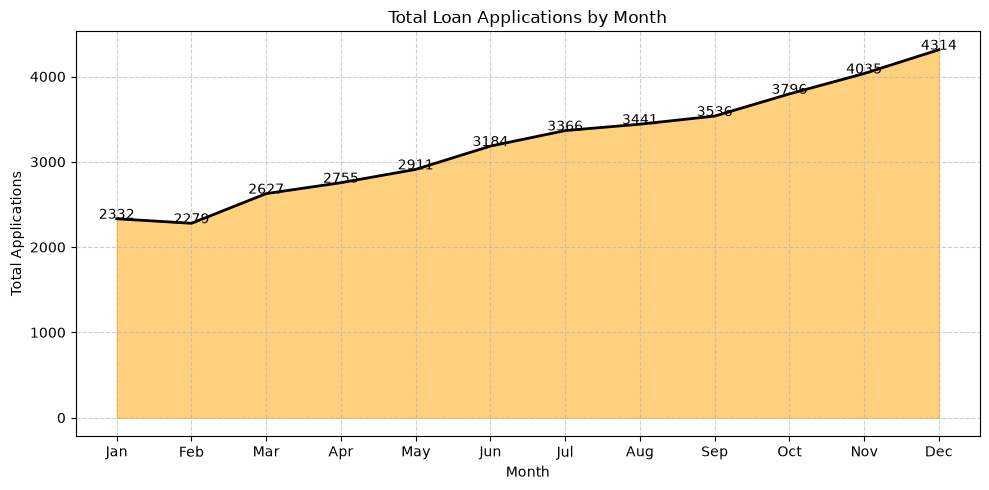

In [31]:
# Sort by date
df = df.sort_values("issue_date")

# Create month name
df["month"] = df["issue_date"].dt.strftime("%b")

# Calculate total Applications for each month
Total_applications= df.groupby("month")["id"].count()

# Arrange months from January to December
month_order = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

Total_applications = Total_applications.reindex(month_order)

# Create chart
plt.figure(figsize=(10, 5))

plt.fill_between(
    Total_applications.index,
    Total_applications.values,
    alpha=0.5,
    color ='orange'
)

plt.plot(
    Total_applications.index,
    Total_applications.values,
    linewidth=2,
    color= 'black'
)

# Add values
for i, value in enumerate(Total_applications.values):
    plt.text(
        i,
        value + 0.1,
        f"{value:}",
        ha="center"
    )

plt.title("Total Loan Applications by Month")
plt.xlabel("Month")
plt.ylabel("Total Applications")

plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

### Regional Analysis by State for Total Funded Amount

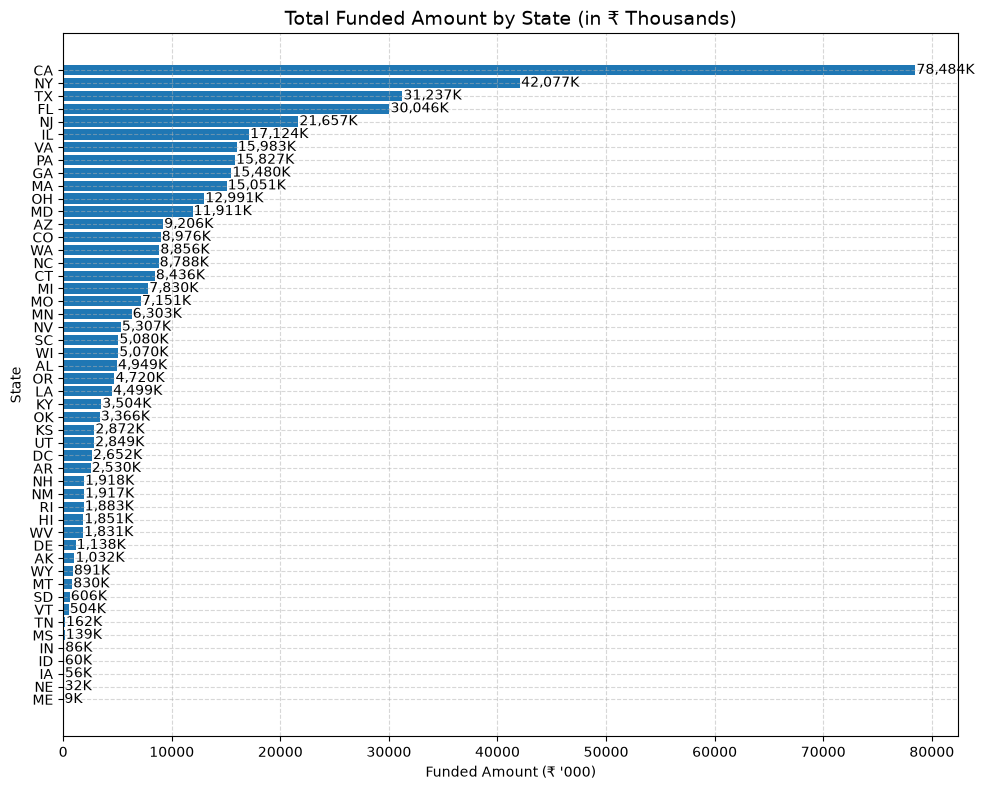

In [38]:
# Calculate total funded amount for each state
state_funded = df.groupby("address_state")["loan_amount"].sum()

# Convert to thousands
state_funded = state_funded / 1000

# Sort from highest to lowest
state_funded = state_funded.sort_values(ascending=False)

# Create horizontal bar chart
plt.figure(figsize=(10, 8))

plt.barh(
    state_funded.index,
    state_funded.values
)

# Put highest state at the top
plt.gca().invert_yaxis()

# Add values at the end of each bar
for i, value in enumerate(state_funded.values):
    plt.text(
        value + 100,
        i,
        f"{value:,.0f}K",
        va="center"
    )

# Title and labels
plt.title("Total Funded Amount by State (in ₹ Thousands)", fontsize=14)
plt.xlabel("Funded Amount (₹ '000)")
plt.ylabel("State")

# Grid
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### Loan Term Analysis By Toatal Funded Amount

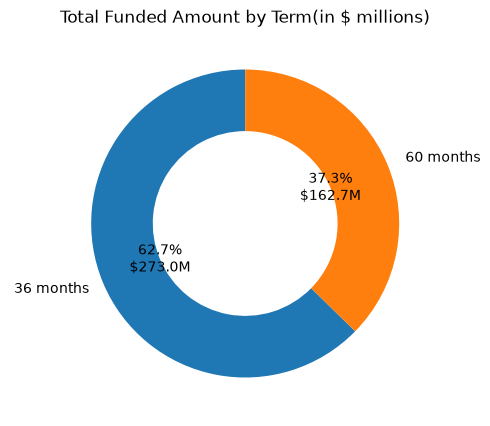

In [40]:
# find total loan amount for each term
term_funding = df.groupby('term')['loan_amount'].sum()

#converting amount into millions
term_funding = term_funding/1000000

def show_values(percent):
    amount = percent * term_funding.sum()/100
    return f"{percent:.1f}%\n${amount:.1f}M"

# create donut chart
plt.figure(figsize=(5,5))

plt.pie(
    term_funding,
    labels=term_funding.index,
    autopct=show_values,
    startangle=90,
    wedgeprops={'width':0.4}
)
plt.title('Total Funded Amount by Term(in $ millions)')
plt.show()

### Employee Length by Total Funded Amount

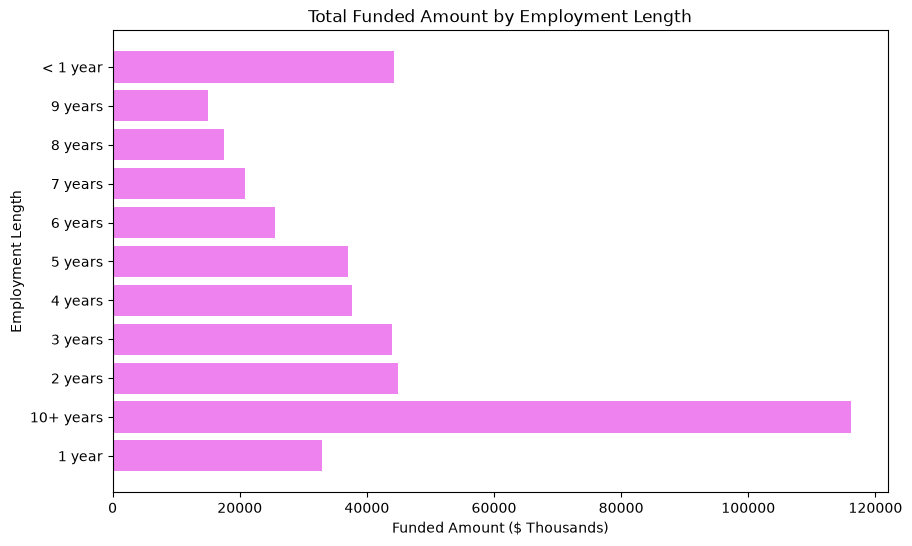

In [46]:
# Total loan amount for each employment length
emp_funding = df.groupby('emp_length')['loan_amount'].sum()

# Convert to thousands
emp_funding = emp_funding / 1000

# Create bar chart
plt.figure(figsize=(10, 6))

plt.barh(emp_funding.index, emp_funding.values,color='violet')

plt.xlabel("Funded Amount ($ Thousands)")
plt.ylabel("Employment Length")
plt.title("Total Funded Amount by Employment Length")

plt.show()

### Loan Purpose by Total Funded Amount 

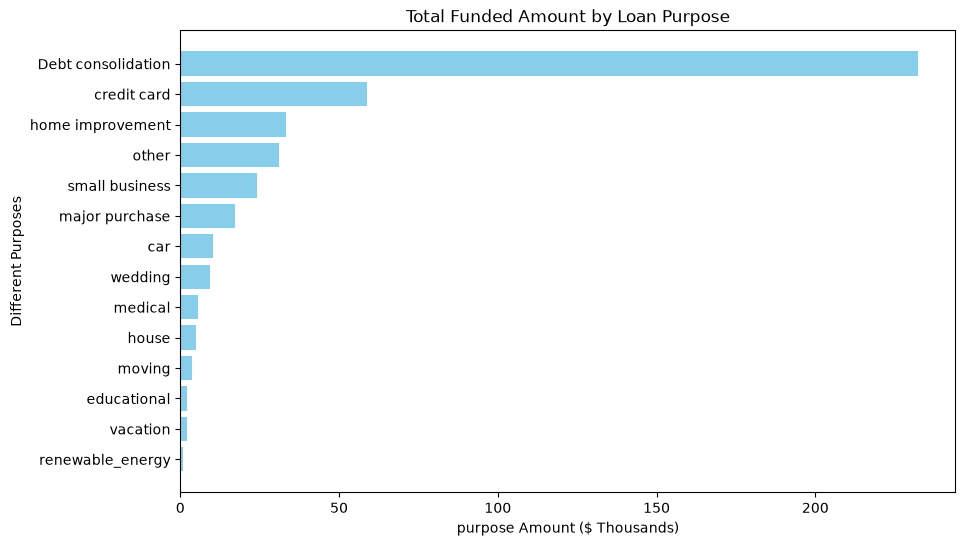

In [51]:
# Total loan amount for each purpose
purpose_funding = df.groupby('purpose')['loan_amount'].sum()

# sort from lowest to highest
purpose_funding = purpose_funding.sort_values()

# Convert to thousands
purpose_funding = purpose_funding / 1000000

# Create bar chart
plt.figure(figsize=(10, 6))

plt.barh(purpose_funding.index, purpose_funding.values,color = 'skyblue')

plt.xlabel("purpose Amount ($ Thousands)")
plt.ylabel("Different Purposes")
plt.title("Total Funded Amount by Loan Purpose")

plt.show()

### Home OwnerShip Analysis by Total Funded Amount

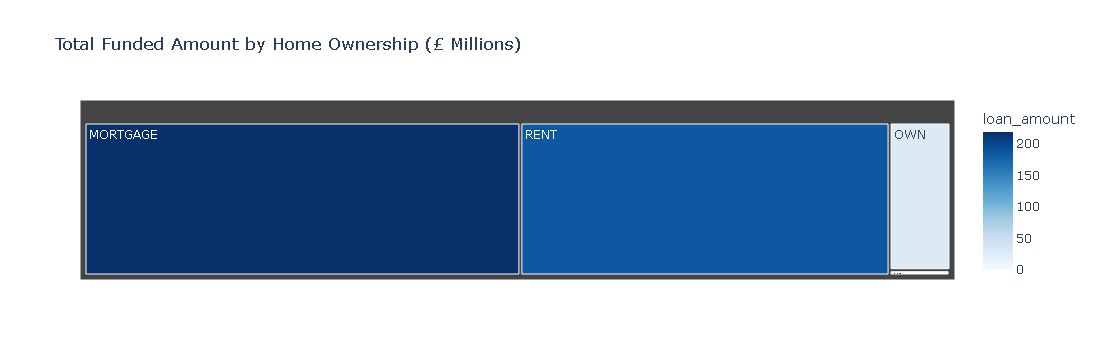

In [55]:
home_funding = df.groupby('home_ownership')['loan_amount'].sum().reset_index()

home_funding['loan_amount'] = home_funding['loan_amount'] / 1000000

fig = px.treemap(
    home_funding,
    path = ['home_ownership'],
    values = 'loan_amount',
    color = 'loan_amount',
    color_continuous_scale = 'Blues',
    title='Total Funded Amount by Home Ownership (£ Millions)'
)

fig.show()